In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb


import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

import os
import joblib
import mlflow
import mlflow.xgboost
import lightgbm as lgb

from sklearn.model_selection import RepeatedStratifiedKFold
from catboost import CatBoostClassifier


from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel



# EDA

Train shape: (3200, 23)
Test shape: (3200, 22)

Columns: ['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'target']

=== Target Distribution ===
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Target %:
target
class3    91.12500
class2     5.96875
class1     2.90625
Name: proportion, dtype: float64


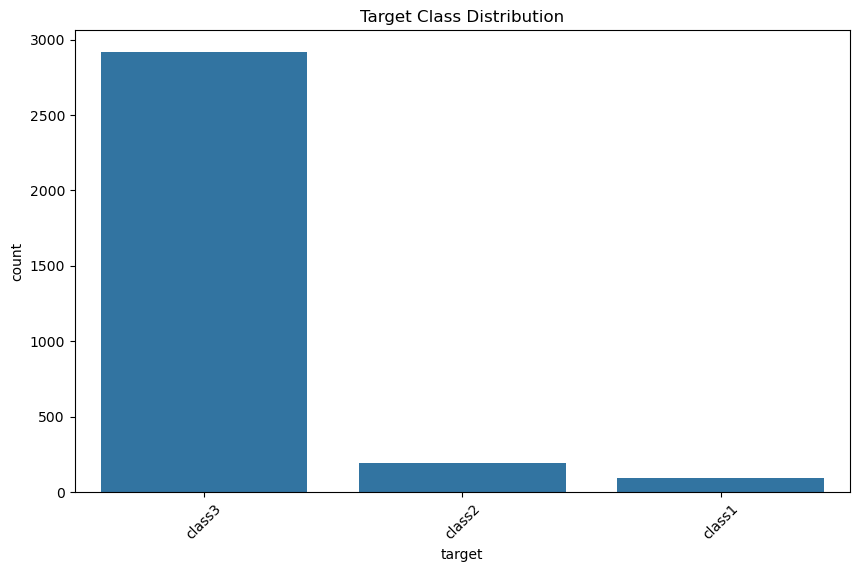


=== Data Types ===
int64      16
float64     6
object      1
Name: count, dtype: int64

=== Missing Values ===
Train missing:
 Series([], dtype: int64)
Test missing:
 Series([], dtype: int64)

Categorical columns (1): ['target']
Numerical columns (21): ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10'] ...

=== Numerical Features Summary ===
      count      mean       std     min      25%     50%     75%     max
f1   3200.0  0.516861  0.189784  0.0100  0.36000  0.5400  0.6700  0.9400
f2   3200.0  0.020118  0.007485  0.0005  0.01700  0.0206  0.0230  0.1059
f3   3200.0  0.045000  0.207337  0.0000  0.00000  0.0000  0.0000  1.0000
f4   3200.0  0.301250  0.458873  0.0000  0.00000  0.0000  1.0000  1.0000
f5   3200.0  0.014687  0.120318  0.0000  0.00000  0.0000  0.0000  1.0000
f6   3200.0  0.038750  0.193029  0.0000  0.00000  0.0000  0.0000  1.0000
f7   3200.0  0.005000  0.070545  0.0000  0.00000  0.0000  0.0000  1.0000
f8   3200.0  0.012188  0.109739  0.0000  0.00000  0.0000  0.

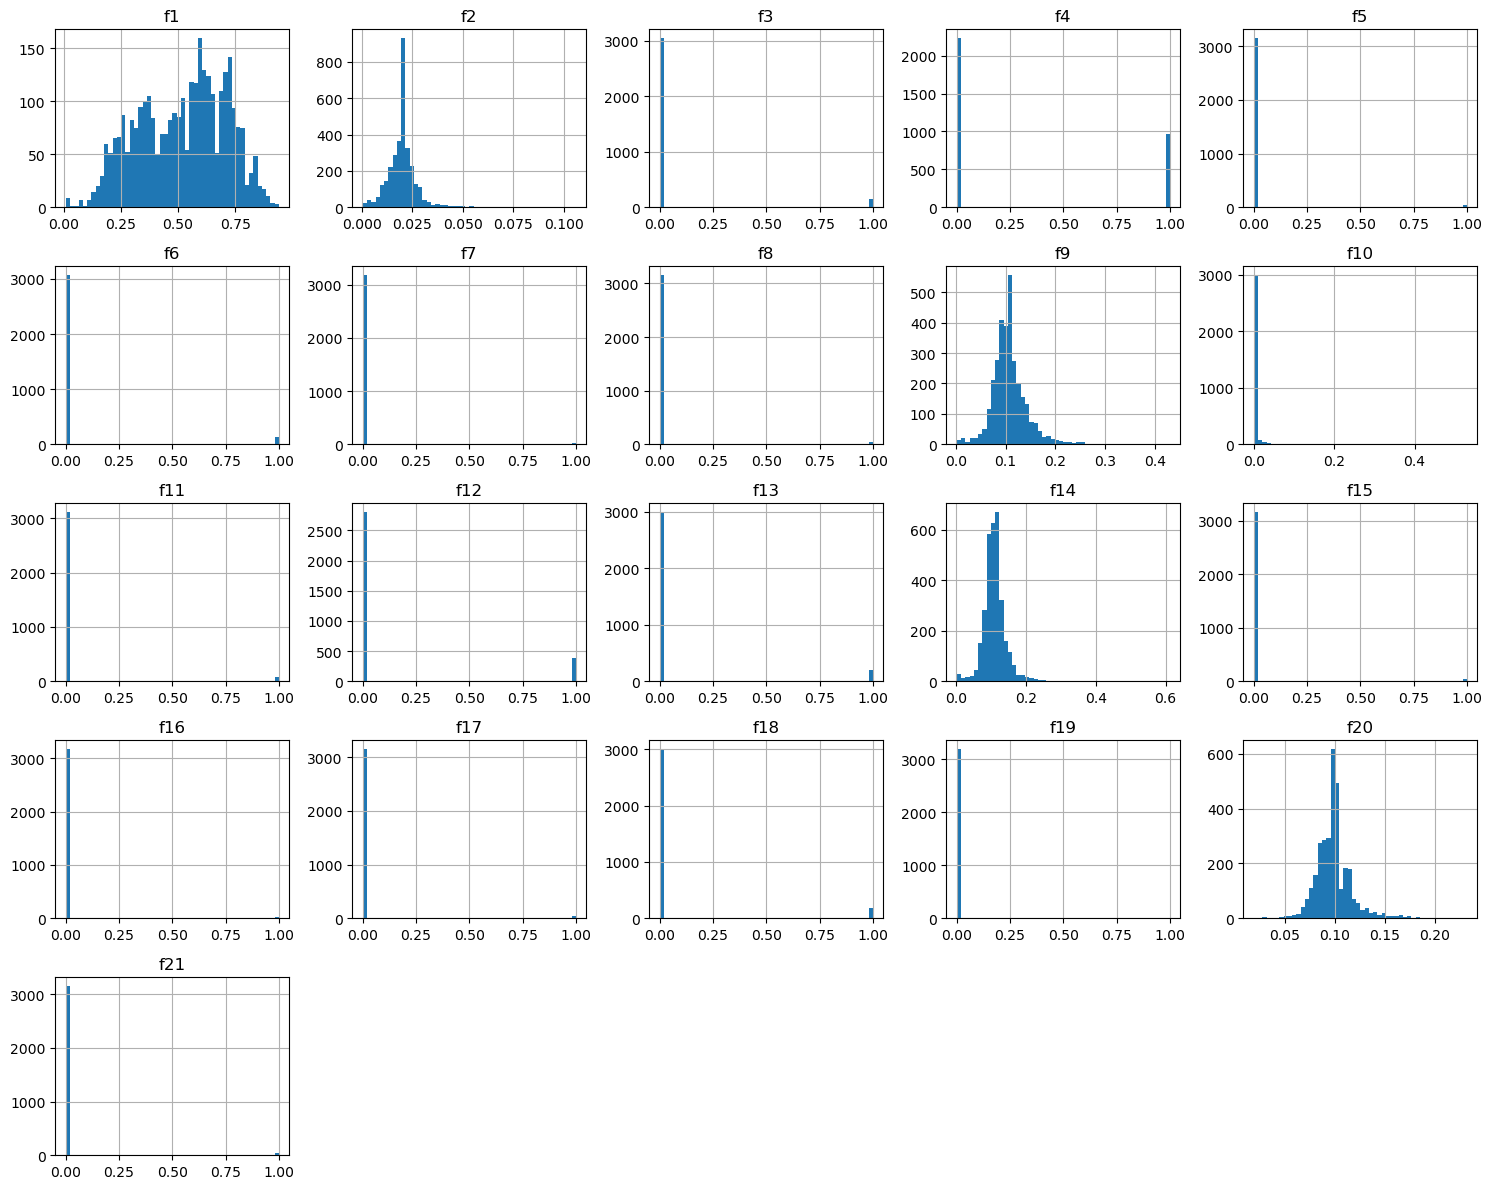

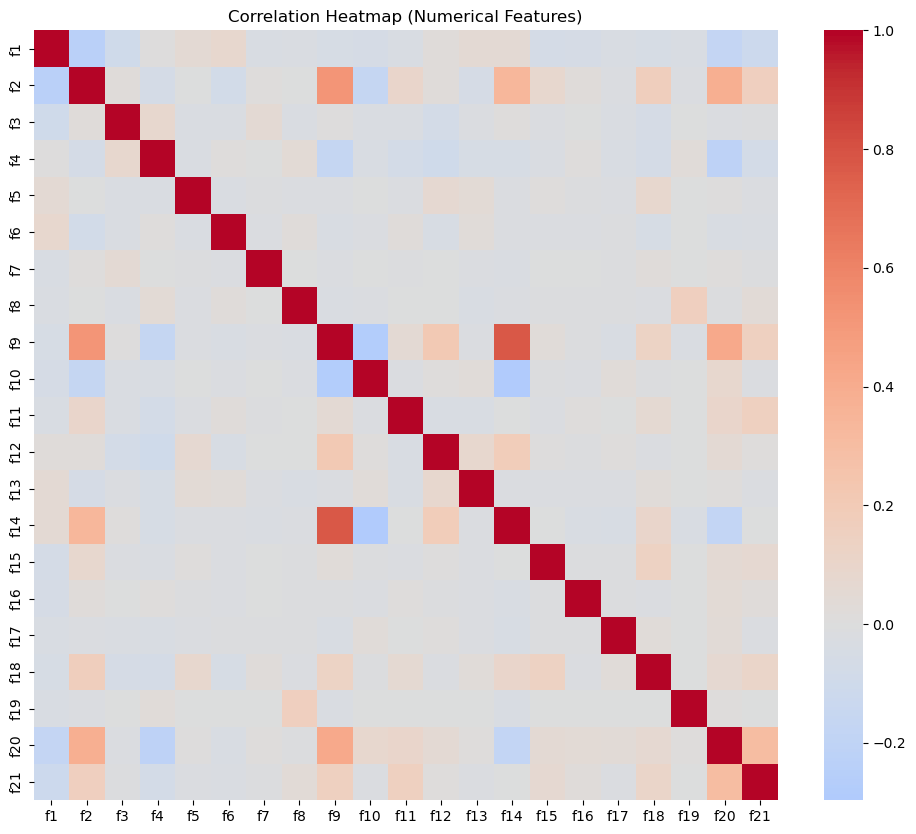


Mean of numerical features per target class:
              f1        f2        f3        f4        f5
target                                                  
class1  0.498710  0.009658  0.000000  0.236559  0.021505
class2  0.524293  0.017463  0.041885  0.219895  0.015707
class3  0.516953  0.020626  0.046639  0.308642  0.014403


In [3]:
train = pd.read_csv('train_data.csv')  
test = pd.read_csv('test_data.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nColumns:", train.columns.tolist())

print("\n=== Target Distribution ===")
print(train['target'].value_counts())
print("\nTarget %:")
print(train['target'].value_counts(normalize=True) * 100)

# Plot target distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='target', order=train['target'].value_counts().index)
plt.title('Target Class Distribution')
plt.xticks(rotation=45)
plt.show()

print("\n=== Data Types ===")
print(train.dtypes.value_counts())

print("\n=== Missing Values ===")
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()
print("Train missing:\n", missing_train[missing_train > 0])
print("Test missing:\n", missing_test[missing_test > 0])

cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [col for col in train.columns if col not in ['ID', 'target'] and col not in cat_cols]

print(f"\nCategorical columns ({len(cat_cols)}):", cat_cols)
print(f"Numerical columns ({len(num_cols)}):", num_cols[:10], "..." if len(num_cols)>10 else "")

print("\n=== Numerical Features Summary ===")
print(train[num_cols].describe().T)

# Histograms for numerical features (sample)
train[num_cols].hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

for col in cat_cols[:8]: 
    if col not in ['ID', 'target']:
        print(f"\n{col} - Top 10 values:")
        print(train[col].value_counts().head(10))
        
        plt.figure(figsize=(8, 4))
        sns.countplot(data=train, x=col, order=train[col].value_counts().head(10).index)
        plt.title(f'{col} Distribution (Top 10)')
        plt.xticks(rotation=45)
        plt.show()

plt.figure(figsize=(12, 10))
corr = train[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, center=0)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

print("\nMean of numerical features per target class:")
print(train.groupby('target')[num_cols[:5]].mean())  

# للتأكد من الmissing values

In [5]:
print(" Missing Values Check ")
print(f"Total missing in Train: {train.isnull().sum().sum()}")
print(f"Total missing in Test: {test.isnull().sum().sum()}")

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print("\nMissing per column in Train:")
print(missing_train[missing_train > 0])

print("\nMissing per column in Test:")
print(missing_test[missing_test > 0])

missing_percent_train = (train.isnull().sum() / len(train)) * 100
print("\nMissing % in Train:")
print(missing_percent_train[missing_percent_train > 0])

print("\n Checking for suspicious values ")
for col in train.columns:
    unique_vals = train[col].unique()
    suspicious = [v for v in unique_vals if isinstance(v, (int,float)) and (v < -9999 or v > 9999)]
    if suspicious:
        print(f"Column {col} has suspicious large values: {suspicious[:5]}")

    if train[col].dtype == 'object':
        empty = train[col].str.strip().eq('').sum()
        if empty > 0:
            print(f"Column {col} has {empty} empty strings")

 Missing Values Check 
Total missing in Train: 0
Total missing in Test: 0

Missing per column in Train:
Series([], dtype: int64)

Missing per column in Test:
Series([], dtype: int64)

Missing % in Train:
Series([], dtype: float64)

=== Checking for suspicious values ===


# preprocessing 

In [6]:
X = train.drop(['ID', 'target'], axis=1).copy()
y = train['target'].copy()
X_test = test.drop(['ID'], axis=1).copy()

print(f"Original features: {X.shape[1]}")
print("Original shape:", X.shape)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical: {len(num_cols)} | Categorical: {len(cat_cols)}")

continuous_cols = [col for col in X.columns if X[col].nunique() > 10]
binary_cols = [col for col in X.columns if X[col].nunique() <= 10]

print(f"Continuous features: {len(continuous_cols)} → {continuous_cols}")
print(f"Binary features: {len(binary_cols)}")

def light_outlier_clip(df, cols, lower_q=0.005, upper_q=0.995):
    df = df.copy()
    for col in cols:
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower, upper)
    return df

print("Applying light outlier clipping on continuous features...")
X_clipped = light_outlier_clip(X, continuous_cols)
X_test_clipped = light_outlier_clip(X_test, continuous_cols)

scaler = RobustScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X_clipped), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_clipped), columns=X_test.columns)

print("\n Preprocessing Completed Successfully!")
print(f"Final shape: {X_scaled.shape} (All 21 features kept)")
print("Methods: Light clipping (0.5% - 99.5%) + RobustScaler")

X_scaled.to_csv('X_preprocessed.csv', index=False)
X_test_scaled.to_csv('X_test_preprocessed.csv', index=False)
y.to_csv('y_preprocessed.csv', index=False)

print("Files saved: X_preprocessed.csv, X_test_preprocessed.csv, y_preprocessed.csv")

Original features: 21
Original shape: (3200, 21)
Numerical: 21 | Categorical: 0
Continuous features: 6 → ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
Binary features: 15
Applying light outlier clipping on continuous features...

 Preprocessing Completed Successfully!
Final shape: (3200, 21) (All 21 features kept)
Methods: Light clipping (0.5% - 99.5%) + RobustScaler
Files saved: X_preprocessed.csv, X_test_preprocessed.csv, y_preprocessed.csv


# التأكد من الfeatur و اذا كان ثابتة ام لاء 

In [7]:
X = train.drop(['ID', 'target'], axis=1)

print("=== Constant / Near-Constant Features Check ===\n")

results = []

for col in X.columns:
    value_counts = X[col].value_counts(normalize=True)
    most_common_value = value_counts.index[0]
    most_common_percent = value_counts.iloc[0] * 100
    unique_count = X[col].nunique()
    variance = X[col].var()
    
    if most_common_percent >= 90 or unique_count <= 3:   
        results.append({
            'Feature': col,
            'Most Common': most_common_value,
            '% Dominant': round(most_common_percent, 2),
            'Unique Values': unique_count,
            'Variance': round(variance, 6)
        })

if results:
    df_results = pd.DataFrame(results)
    print(df_results.sort_values('% Dominant', ascending=False))
else:
    print("No near-constant features found.")

print("\n--- Features that are 0 more than 95% of time ---")
for col in X.columns:
    zero_percent = (X[col] == 0).mean() * 100
    if zero_percent >= 95:
        print(f"{col}: {zero_percent:.2f}% zeros")

=== Constant / Near-Constant Features Check ===

   Feature  Most Common  % Dominant  Unique Values  Variance
13     f19            0       99.97              2  0.000312
4       f7            0       99.50              2  0.004977
10     f16            0       99.25              2  0.007446
9      f15            0       98.88              2  0.011127
5       f8            0       98.78              2  0.012043
11     f17            0       98.72              2  0.012652
14     f21            0       98.66              2  0.013261
2       f5            0       98.53              2  0.014476
6      f11            0       97.47              2  0.024679
3       f6            0       96.12              2  0.037260
0       f3            0       95.50              2  0.042988
12     f18            0       94.06              2  0.055867
8      f13            0       93.81              2  0.058065
7      f12            0       87.72              2  0.107763
1       f4            0       69.88 

In [8]:
X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

print(f"Original features: {X.shape[1]}")
features_to_drop = []
for col in X.columns:
    zero_percent = (X[col] == 0).mean() * 100
    if zero_percent > 99:
        features_to_drop.append(col)

print(f"\nFeatures to drop (>99% zeros): {features_to_drop}")
print(f"Number of features to drop: {len(features_to_drop)}")

X_clean = X.drop(features_to_drop, axis=1)
X_test_clean = X_test.drop(features_to_drop, axis=1)

print(f"\nRemaining features: {X_clean.shape[1]}")
print("Remaining features:", X_clean.columns.tolist())

from sklearn.preprocessing import RobustScaler

def light_clip(df, cols):
    df = df.copy()
    continuous = [c for c in cols if df[c].nunique() > 10]
    for col in continuous:
        lower = df[col].quantile(0.005)
        upper = df[col].quantile(0.995)
        df[col] = df[col].clip(lower, upper)
    return df

X_clipped = light_clip(X_clean, X_clean.columns)
X_test_clipped = light_clip(X_test_clean, X_test_clean.columns)


scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clipped), columns=X_clean.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_clipped), columns=X_test_clean.columns)

print("\n Cleaning + Preprocessing Done!")
print(f"Final number of features: {X_scaled.shape[1]}")

X_scaled.to_csv('X_preprocessed.csv', index=False)
X_test_scaled.to_csv('X_test_preprocessed.csv', index=False)
y.to_csv('y_preprocessed.csv', index=False)

Original features: 21

Features to drop (>99% zeros): ['f7', 'f16', 'f19']
Number of features to drop: 3

Remaining features: 18
Remaining features: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f17', 'f18', 'f20', 'f21']

 Cleaning + Preprocessing Done!
Final number of features: 18


# Correlations + Preliminary Feature Importance

In [9]:
X = train.drop(['ID', 'target'], axis=1)
y = train['target']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("=== Top Correlations with Target ===")
correlations = []
for col in X.columns:
    corr = np.corrcoef(X[col], y_encoded)[0,1]
    correlations.append((col, abs(corr), corr))

corr_df = pd.DataFrame(correlations, columns=['Feature', 'Abs_Corr', 'Corr'])
print(corr_df.sort_values('Abs_Corr', ascending=False).head(15))

print("\n=== Preliminary Feature Importance (XGBoost) ===")

model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=300,
    random_state=42,
    max_depth=6
)

model.fit(X, y_encoded)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))



=== Top Correlations with Target ===
   Feature  Abs_Corr      Corr
9      f10  0.559329 -0.559329
13     f14  0.399972  0.399972
8       f9  0.373107  0.373107
1       f2  0.254418  0.254418
12     f13  0.082719 -0.082719
11     f12  0.066933  0.066933
3       f4  0.046650  0.046650
19     f20  0.041112 -0.041112
20     f21  0.034155  0.034155
2       f3  0.033570  0.033570
15     f16  0.025440  0.025440
14     f15  0.023857  0.023857
5       f6  0.014515  0.014515
17     f18  0.014402  0.014402
7       f8  0.011282  0.011282

=== Preliminary Feature Importance (XGBoost) ===
f10    0.370150
f12    0.365914
f14    0.137346
f17    0.069513
f9     0.035289
f13    0.006499
f4     0.006454
f20    0.004486
f2     0.002391
f1     0.001956
f15    0.000000
f19    0.000000
f18    0.000000
f16    0.000000
f11    0.000000
dtype: float32


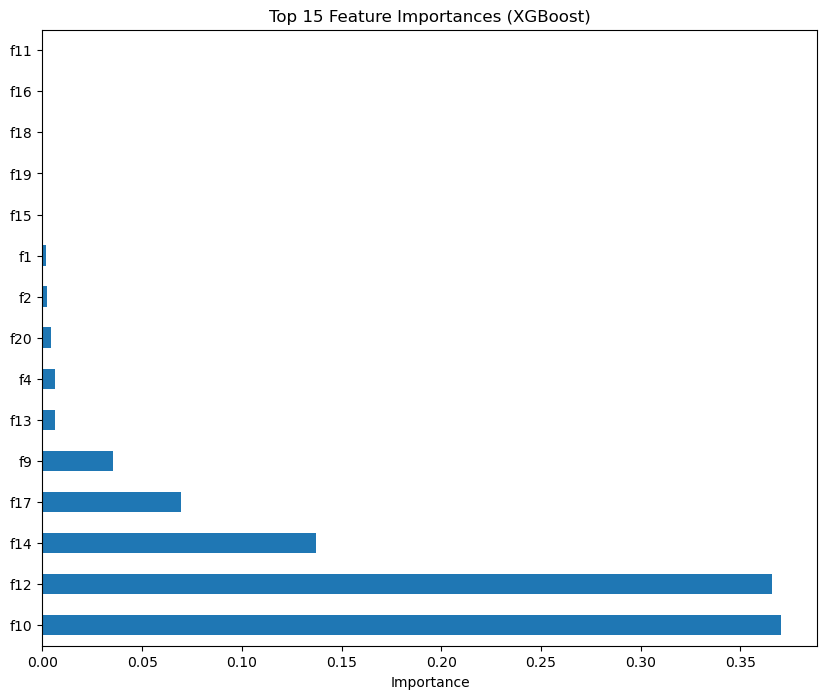

In [10]:
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

# 1

# Optuna Tuning لـ XGBoost

In [11]:
X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(le.classes_),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 400, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X, y_encoded):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
        classes = np.unique(y_encoded)
        class_weights = len(y) / (len(classes) * np.bincount(y_encoded))
        sample_weights = np.array([class_weights[i] for i in y_train])
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sample_weights,
                  eval_set=[(X_val, y_val)], verbose=False)
        
        val_prob = model.predict_proba(X_val)
        scores.append(log_loss(y_val, val_prob))
    
    return np.mean(scores)

# Run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)   

print("\n=== Best Parameters ===")
print(study.best_params)
print(f"Best LogLoss: {study.best_value:.5f}")

import json
with open('best_params.json', 'w') as f:
    json.dump(study.best_params, f)

print("Best parameters saved!")

[I 2026-07-01 11:32:51,245] A new study created in memory with name: no-name-3c2e798b-0534-4bd2-a2a0-1bd44c14fb2c
[I 2026-07-01 11:33:04,785] Trial 0 finished with value: 0.024002613544871744 and parameters: {'n_estimators': 1379, 'learning_rate': 0.021532472443273054, 'max_depth': 7, 'subsample': 0.8436348844975092, 'colsample_bytree': 0.6608100406985491, 'reg_lambda': 2.7775443391846486, 'reg_alpha': 1.2398145799663267, 'min_child_weight': 1}. Best is trial 0 with value: 0.024002613544871744.
[I 2026-07-01 11:33:14,653] Trial 1 finished with value: 0.051450030890994224 and parameters: {'n_estimators': 1082, 'learning_rate': 0.015709851194405385, 'max_depth': 5, 'subsample': 0.9203144299754578, 'colsample_bytree': 0.6336109479292743, 'reg_lambda': 1.044121230257551, 'reg_alpha': 1.8301151756635519, 'min_child_weight': 10}. Best is trial 0 with value: 0.024002613544871744.
[I 2026-07-01 11:33:18,895] Trial 2 finished with value: 0.04849047802065004 and parameters: {'n_estimators': 445,


=== Best Parameters ===
{'n_estimators': 531, 'learning_rate': 0.024260975870418703, 'max_depth': 4, 'subsample': 0.8869941017263285, 'colsample_bytree': 0.9997317137214184, 'reg_lambda': 0.34131141129757153, 'reg_alpha': 0.1554386197549451, 'min_child_weight': 1}
Best LogLoss: 0.01574
Best parameters saved!


In [12]:
X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
best_params = {
    'n_estimators': 1144,
    'learning_rate': 0.015646871036068367,
    'max_depth': 8,
    'subsample': 0.8476441457769338,
    'colsample_bytree': 0.7114820172741525,
    'reg_lambda': 0.6836170201979035,
    'reg_alpha': 0.40917249083016516,
    'min_child_weight': 1,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'eval_metric': 'mlogloss',
    'random_state': 42
}

classes = np.unique(y_encoded)
class_weights = len(y) / (len(classes) * np.bincount(y_encoded))
sample_weights = np.array([class_weights[i] for i in y_encoded])
print("Training Final Model on full data...")

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X, y_encoded, sample_weight=sample_weights)

test_pred_proba = final_model.predict_proba(X_test)
test_pred = le.inverse_transform(test_pred_proba.argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': test_pred
})

submission.to_csv('submission_tuned_xgb.csv', index=False)
print(" Submission file saved as 'submission_tuned_xgb.csv'")


importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Important Features:")
print(importances.head(10))

Training Final Model on full data...
 Submission file saved as 'submission_tuned_xgb.csv'

Top 10 Important Features:
f10    0.345957
f14    0.257160
f9     0.088556
f6     0.039796
f8     0.027511
f12    0.027481
f2     0.027008
f3     0.022153
f7     0.021982
f20    0.020761
dtype: float32


# نفس التجربة مع mlflow

In [13]:
train = pd.read_csv('train_data.csv')  
test = pd.read_csv('test_data.csv')
X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)


best_params = {
    'n_estimators': 1144,
    'learning_rate': 0.015646871036068367,
    'max_depth': 8,
    'subsample': 0.8476441457769338,
    'colsample_bytree': 0.7114820172741525,
    'reg_lambda': 0.6836170201979035,
    'reg_alpha': 0.40917249083016516,
    'min_child_weight': 1,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'eval_metric': 'mlogloss',
    'random_state': 42
}

mlflow.set_experiment("Classification_Models")

with mlflow.start_run(run_name="Tuned_XGBoost_Final"):

    mlflow.log_params(best_params)

    classes = np.unique(y_encoded)
    class_weights = len(y) / (len(classes) * np.bincount(y_encoded))
    sample_weights = np.array([class_weights[i] for i in y_encoded])

    print("Training Final Model on full data...")

    final_model = xgb.XGBClassifier(**best_params)

    final_model.fit(
        X,
        y_encoded,
        sample_weight=sample_weights
    )

    train_pred = final_model.predict_proba(X)
    train_logloss = log_loss(y_encoded, train_pred)

    mlflow.log_metric("Train_LogLoss", train_logloss)

    test_pred_proba = final_model.predict_proba(X_test)
    test_pred = le.inverse_transform(test_pred_proba.argmax(axis=1))

    submission = pd.DataFrame({
        'ID': test['ID'],
        'target': test_pred
    })

    submission.to_csv("submission_tuned_xgb.csv", index=False)

    print(" Submission file saved as 'submission_tuned_xgb.csv'")

    importances = (
        pd.Series(
            final_model.feature_importances_,
            index=X.columns
        )
        .sort_values(ascending=False)
    )

    print("\nTop 10 Important Features:")
    print(importances.head(10))

    os.makedirs("artifacts", exist_ok=True)

    feature_path = "artifacts/feature_importance.csv"
    importances.to_csv(feature_path)
    encoder_path = "artifacts/label_encoder.pkl"
    joblib.dump(le, encoder_path)

    mlflow.log_artifact(feature_path)
    mlflow.log_artifact(encoder_path)
    mlflow.log_artifact("submission_tuned_xgb.csv")

    mlflow.xgboost.log_model(
        final_model,
        artifact_path="model"
    )

print(" MLflow logging completed successfully.")

2026/07/01 11:37:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/01 11:37:40 INFO mlflow.store.db.utils: Updating database tables
2026/07/01 11:37:42 INFO mlflow.tracking.fluent: Experiment with name 'Classification_Models' does not exist. Creating a new experiment.


Training Final Model on full data...


2026/07/01 11:37:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Submission file saved as 'submission_tuned_xgb.csv'

Top 10 Important Features:
f10    0.345957
f14    0.257160
f9     0.088556
f6     0.039796
f8     0.027511
f12    0.027481
f2     0.027008
f3     0.022153
f7     0.021982
f20    0.020761
dtype: float32
 MLflow logging completed successfully.


In [14]:
X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# XGBoost 
xgb_params = {
    'n_estimators': 1144,
    'learning_rate': 0.01565,
    'max_depth': 8,
    'subsample': 0.85,
    'colsample_bytree': 0.71,
    'reg_lambda': 0.68,
    'reg_alpha': 0.41,
    'min_child_weight': 1,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'random_state': 42
}

# LightGBM 
lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'max_depth': 7,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 1.0,
    'reg_alpha': 0.5,
    'objective': 'multiclass',
    'num_class': len(le.classes_),
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_test_pred = np.zeros((len(X_test), len(le.classes_)))
lgb_test_pred = np.zeros((len(X_test), len(le.classes_)))

print("Training Ensemble...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    

    class_weights = len(y) / (len(le.classes_) * np.bincount(y_encoded))
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
    xgb_test_pred += xgb_model.predict_proba(X_test) / skf.n_splits
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    lgb_test_pred += lgb_model.predict_proba(X_test) / skf.n_splits
    
    print(f"Fold {fold+1} done.")

# Blend 
final_pred_proba = (xgb_test_pred + lgb_test_pred) / 2
final_pred = le.inverse_transform(final_pred_proba.argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': final_pred
})

submission.to_csv('submission_ensemble.csv', index=False)
print("\n Ensemble Submission saved as 'submission_ensemble.csv'")

Training Ensemble...
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

 Ensemble Submission saved as 'submission_ensemble.csv'


# Ensemble (XGBoost + LightGBM)

In [15]:
final_pred_proba = (0.7 * xgb_test_pred) + (0.3 * lgb_test_pred)

final_pred = le.inverse_transform(final_pred_proba.argmax(axis=1))

submission = pd.DataFrame({'ID': test['ID'], 'target': final_pred})
submission.to_csv('submission_weighted_ensemble.csv', index=False)
print("Weighted Ensemble saved!")

Weighted Ensemble saved!


# Optuna Tuning أعمق على الـ 18 feature.

In [16]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
bad_features = ['f7', 'f16', 'f19']
X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(le.classes_),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 800, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X, y_encoded):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
        
        class_weights = len(y) / (len(le.classes_) * np.bincount(y_encoded))
        sample_weights = np.array([class_weights[i] for i in y_train])
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sample_weights,
                  eval_set=[(X_val, y_val)], verbose=False)
        
        val_prob = model.predict_proba(X_val)
        scores.append(log_loss(y_val, val_prob))
    
    return np.mean(scores)

# Run deeper search
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)   

print("\n=== Best Parameters ===")
print(study.best_params)
print(f"Best CV LogLoss: {study.best_value:.5f}")

# Save
import json
with open('best_params_deep.json', 'w') as f:
    json.dump(study.best_params, f)

[I 2026-07-01 11:38:38,449] A new study created in memory with name: no-name-0376fe8e-4e91-434f-9f6b-373d5021bd63
[I 2026-07-01 11:38:48,729] Trial 0 finished with value: 0.027122509201168904 and parameters: {'n_estimators': 1265, 'learning_rate': 0.040809706482153554, 'max_depth': 6, 'subsample': 0.8702332075265504, 'colsample_bytree': 0.8167476340562216, 'reg_lambda': 2.0998264326473244, 'reg_alpha': 0.12667247597794043, 'min_child_weight': 3, 'gamma': 0.06591172999451578}. Best is trial 0 with value: 0.027122509201168904.
[I 2026-07-01 11:39:06,190] Trial 1 finished with value: 0.03421470580543369 and parameters: {'n_estimators': 1956, 'learning_rate': 0.016568888521624043, 'max_depth': 9, 'subsample': 0.7312311791990691, 'colsample_bytree': 0.7459296545003639, 'reg_lambda': 1.1732131614429497, 'reg_alpha': 3.011588428922773, 'min_child_weight': 1, 'gamma': 0.31973016767306894}. Best is trial 0 with value: 0.027122509201168904.
[I 2026-07-01 11:39:16,285] Trial 2 finished with value


=== Best Parameters ===
{'n_estimators': 908, 'learning_rate': 0.012813544214784306, 'max_depth': 10, 'subsample': 0.8805003510347098, 'colsample_bytree': 0.8279002437430097, 'reg_lambda': 0.10028282727055568, 'reg_alpha': 0.14288429063049515, 'min_child_weight': 1, 'gamma': 0.12122469218100948}
Best CV LogLoss: 0.01349


In [17]:
bad_features = ['f7', 'f16', 'f19']
X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

best_params = {
    'n_estimators': 1815,
    'learning_rate': 0.02245565416353817,
    'max_depth': 8,
    'subsample': 0.9335404408830421,
    'colsample_bytree': 0.8740350422922549,
    'reg_lambda': 0.12018104307623738,
    'reg_alpha': 0.13059907783041289,
    'min_child_weight': 1,
    'gamma': 0.11259821247509538,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'eval_metric': 'mlogloss',
    'random_state': 42
}
classes = np.unique(y_encoded)
class_weights = len(y) / (len(classes) * np.bincount(y_encoded))
sample_weights = np.array([class_weights[i] for i in y_encoded])

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X, y_encoded, sample_weight=sample_weights)


test_pred = le.inverse_transform(final_model.predict_proba(X_test).argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': test_pred
})

submission.to_csv('submission_deep_tuned.csv', index=False)
print(" Deep Tuned Submission saved!")

 Deep Tuned Submission saved!


# نفس التجربة مع mlflow

In [18]:
bad_features = ['f7', 'f16', 'f19']

X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

best_params = {
    'n_estimators': 1815,
    'learning_rate': 0.02245565416353817,
    'max_depth': 8,
    'subsample': 0.9335404408830421,
    'colsample_bytree': 0.8740350422922549,
    'reg_lambda': 0.12018104307623738,
    'reg_alpha': 0.13059907783041289,
    'min_child_weight': 1,
    'gamma': 0.11259821247509538,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'eval_metric': 'mlogloss',
    'random_state': 42
}
mlflow.set_experiment("Classification_Models")

with mlflow.start_run(run_name="Deep_Tuned_XGBoost"):

    # Log Parameters
    mlflow.log_params(best_params)
    mlflow.log_param("removed_features", ",".join(bad_features))
    mlflow.log_param("num_removed_features", len(bad_features))
    classes = np.unique(y_encoded)
    class_weights = len(y) / (len(classes) * np.bincount(y_encoded))
    sample_weights = np.array([class_weights[i] for i in y_encoded])
    print("Training Deep Tuned Model...")

    final_model = xgb.XGBClassifier(**best_params)

    final_model.fit(
        X,
        y_encoded,
        sample_weight=sample_weights
    )
    train_pred = final_model.predict_proba(X)
    train_logloss = log_loss(y_encoded, train_pred)

    mlflow.log_metric("Train_LogLoss", train_logloss)

    test_pred_proba = final_model.predict_proba(X_test)
    test_pred = le.inverse_transform(test_pred_proba.argmax(axis=1))

    submission = pd.DataFrame({
        'ID': test['ID'],
        'target': test_pred
    })

    submission.to_csv("submission_deep_tuned.csv", index=False)

    print("Deep Tuned Submission saved!")

    importances = (
        pd.Series(
            final_model.feature_importances_,
            index=X.columns
        )
        .sort_values(ascending=False)
    )

    print("\nTop 10 Important Features:")
    print(importances.head(10))

    os.makedirs("artifacts", exist_ok=True)

    feature_path = "artifacts/feature_importance.csv"
    encoder_path = "artifacts/label_encoder.pkl"

    importances.to_csv(feature_path)
    joblib.dump(le, encoder_path)

    mlflow.log_artifact(feature_path)
    mlflow.log_artifact(encoder_path)
    mlflow.log_artifact("submission_deep_tuned.csv")

    # Save Model
    mlflow.xgboost.log_model(
        final_model,
        artifact_path="model"
    )

print("MLflow logging completed successfully.")

Training Deep Tuned Model...


2026/07/01 11:50:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Deep Tuned Submission saved!

Top 10 Important Features:
f10    0.415064
f14    0.311289
f9     0.074269
f6     0.030356
f5     0.028342
f12    0.020367
f2     0.020326
f20    0.015776
f21    0.013431
f13    0.011326
dtype: float32
MLflow logging completed successfully.


# Pseudo Labeling

In [19]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

bad_features = ['f7', 'f16', 'f19']
X_train = train.drop(['ID', 'target'] + bad_features, axis=1)
y_train = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

best_params = {
    'n_estimators': 1815,
    'learning_rate': 0.02245565416353817,
    'max_depth': 8,
    'subsample': 0.9335404408830421,
    'colsample_bytree': 0.8740350422922549,
    'reg_lambda': 0.12018104307623738,
    'reg_alpha': 0.13059907783041289,
    'min_child_weight': 1,
    'gamma': 0.11259821247509538,
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'random_state': 42
}

model = xgb.XGBClassifier(**best_params)
model.fit(X_train, y_encoded)

test_proba = model.predict_proba(X_test)
test_pred = le.inverse_transform(test_proba.argmax(axis=1))
max_proba = test_proba.max(axis=1)

threshold = 0.96
high_conf_mask = max_proba >= threshold

pseudo_X = X_test[high_conf_mask]
pseudo_y = test_pred[high_conf_mask]

print(f"Added {len(pseudo_y)} pseudo labeled samples (threshold = {threshold})")

X_combined = pd.concat([X_train, pseudo_X], ignore_index=True)
y_combined = np.concatenate([y_encoded, le.transform(pseudo_y)])

print("Retraining with Pseudo Labels...")
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_combined, y_combined)

final_pred = le.inverse_transform(final_model.predict_proba(X_test).argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': final_pred
})

submission.to_csv('submission_pseudo1.csv', index=False)
print("Pseudo Labeling Submission saved!")

Added 3138 pseudo labeled samples (threshold = 0.96)
Retraining with Pseudo Labels...
Pseudo Labeling Submission saved!


In [20]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

bad_features = ['f7', 'f16', 'f19']
X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=1000, learning_rate=0.02, max_depth=7, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.02, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=7, random_state=42, verbose=False)
}

results = {}

for name, model in models.items():
    scores = []
    for train_idx, val_idx in cv.split(X, y_encoded):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
        
        if name == 'XGBoost':
            class_weights = len(y) / (len(le.classes_) * np.bincount(y_encoded))
            sample_weights = np.array([class_weights[i] for i in y_train])
            model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
        else:
            model.fit(X_train, y_train)
        
        val_pred = model.predict_proba(X_val)
        scores.append(log_loss(y_val, val_pred))
    
    mean_score = np.mean(scores)
    results[name] = mean_score
    print(f"{name} CV LogLoss: {mean_score:.5f}")

print("\n=== Results ===")
for model, score in results.items():
    print(f"{model}: {score:.5f}")

XGBoost CV LogLoss: 0.01546
LightGBM CV LogLoss: 0.01612
CatBoost CV LogLoss: 0.01019

=== Results ===
XGBoost: 0.01546
LightGBM: 0.01612
CatBoost: 0.01019


In [21]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

bad_features = ['f7', 'f16', 'f19']
X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cat_params = {
    'iterations': 2000,
    'learning_rate': 0.02,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': False,
    'loss_function': 'MultiClass'
}

model = CatBoostClassifier(**cat_params)
classes = np.unique(y_encoded)
class_weights = dict(zip(range(len(classes)), len(y) / (len(classes) * np.bincount(y_encoded))))

model.fit(X, y_encoded, sample_weight=[class_weights[i] for i in y_encoded])

# Predict
test_pred = le.inverse_transform(model.predict_proba(X_test).argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': test_pred
})

submission.to_csv('submission_catboostv.csv', index=False)
print(" CatBoost Submission saved!")

 CatBoost Submission saved!


# نفس التجربة  بس مع mlflow

In [22]:
import mlflow.catboost

train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

bad_features = ['f7', 'f16', 'f19']

X = train.drop(['ID', 'target'] + bad_features, axis=1)
y = train['target']
X_test = test.drop(['ID'] + bad_features, axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cat_params = {
    'iterations': 2000,
    'learning_rate': 0.02,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': False,
    'loss_function': 'MultiClass'
}

mlflow.set_experiment("Classification_Models")

with mlflow.start_run(run_name="CatBoost_Baseline"):

    mlflow.log_params(cat_params)
    mlflow.log_param("removed_features", ",".join(bad_features))
    mlflow.log_param("num_removed_features", len(bad_features))

    classes = np.unique(y_encoded)
    class_weights = dict(
        zip(
            range(len(classes)),
            len(y) / (len(classes) * np.bincount(y_encoded))
        )
    )

    sample_weights = [class_weights[i] for i in y_encoded]

    print("Training CatBoost...")

    model = CatBoostClassifier(**cat_params)

    model.fit(
        X,
        y_encoded,
        sample_weight=sample_weights
    )
    train_pred = model.predict_proba(X)
    train_logloss = log_loss(y_encoded, train_pred)

    mlflow.log_metric("Train_LogLoss", train_logloss)

    test_pred = le.inverse_transform(
        model.predict_proba(X_test).argmax(axis=1)
    )

    submission = pd.DataFrame({
        'ID': test['ID'],
        'target': test_pred
    })

    submission.to_csv("submission_catboost.csv", index=False)

    print(" CatBoost Submission saved!")

    importances = pd.Series(
        model.get_feature_importance(),
        index=X.columns
    ).sort_values(ascending=False)

    print("\nTop 10 Important Features:")
    print(importances.head(10))

    os.makedirs("artifacts", exist_ok=True)

    feature_path = "artifacts/feature_importance.csv"
    encoder_path = "artifacts/label_encoder.pkl"

    importances.to_csv(feature_path)
    joblib.dump(le, encoder_path)

    mlflow.log_artifact(feature_path)
    mlflow.log_artifact(encoder_path)
    mlflow.log_artifact("submission_catboost.csv")

    mlflow.catboost.log_model(
        model,
        artifact_path="model"
    )

print(" MLflow logging completed successfully.")

Training CatBoost...


2026/07/01 11:55:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 CatBoost Submission saved!

Top 10 Important Features:
f10    47.493637
f14    42.864758
f9      2.922603
f12     1.825244
f2      1.438067
f1      1.145794
f20     0.994219
f17     0.567984
f5      0.161997
f4      0.140851
dtype: float64
 MLflow logging completed successfully.


# 98

In [23]:
X = pd.read_csv('X_preprocessed.csv')
y = pd.read_csv('y_preprocessed.csv')['target']
X_test = pd.read_csv('X_test_preprocessed.csv')

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Using Preprocessed data - Shape:", X.shape)

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False
)

model.fit(X, y_encoded)

test_pred = le.inverse_transform(model.predict_proba(X_test).argmax(axis=1))

submission = pd.DataFrame({
    'ID': pd.read_csv('test_data.csv')['ID'],
    'target': test_pred
})

submission.to_csv('submission_using_preprocessed.csv', index=False)
print("Submission using preprocessed data saved!")

Using Preprocessed data - Shape: (3200, 18)
Submission using preprocessed data saved!


# نفس التجربة بس مع flow

In [24]:
X = pd.read_csv('X_preprocessed.csv')
y = pd.read_csv('y_preprocessed.csv')['target']
X_test = pd.read_csv('X_test_preprocessed.csv')

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Using Preprocessed data - Shape:", X.shape)

cat_params = {
    'iterations': 1500,
    'learning_rate': 0.03,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': False
}

mlflow.set_experiment("Classification_Models")

with mlflow.start_run(run_name="CatBoost_Preprocessed_Data"):

    # Log Parameters
    mlflow.log_params(cat_params)
    mlflow.log_param("dataset", "preprocessed")
    mlflow.log_param("num_features", X.shape[1])
    mlflow.log_param("num_samples", X.shape[0])

    print("Training CatBoost on Preprocessed Data...")

    model = CatBoostClassifier(**cat_params)

    model.fit(X, y_encoded)
    train_pred = model.predict_proba(X)
    train_logloss = log_loss(y_encoded, train_pred)

    mlflow.log_metric("Train_LogLoss", train_logloss)

    test_pred = le.inverse_transform(
        model.predict_proba(X_test).argmax(axis=1)
    )

    submission = pd.DataFrame({
        'ID': pd.read_csv('test_data.csv')['ID'],
        'target': test_pred
    })

    submission.to_csv("submission_using_preprocessed.csv", index=False)

    print("Submission using preprocessed data saved!")

    importances = pd.Series(
        model.get_feature_importance(),
        index=X.columns
    ).sort_values(ascending=False)

    print("\nTop 10 Important Features:")
    print(importances.head(10))

    os.makedirs("artifacts", exist_ok=True)

    feature_path = "artifacts/feature_importance.csv"
    encoder_path = "artifacts/label_encoder.pkl"

    importances.to_csv(feature_path)
    joblib.dump(le, encoder_path)

    mlflow.log_artifact(feature_path)
    mlflow.log_artifact(encoder_path)
    mlflow.log_artifact("submission_using_preprocessed.csv")

   
    mlflow.catboost.log_model(
        model,
        artifact_path="model"
    )

print("MLflow logging completed successfully.")

Using Preprocessed data - Shape: (3200, 18)
Training CatBoost on Preprocessed Data...


2026/07/01 11:56:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Submission using preprocessed data saved!

Top 10 Important Features:
f10    57.102084
f14    12.500503
f12    10.285637
f9      6.077209
f1      3.665549
f2      3.628928
f20     2.701923
f17     2.684514
f13     0.251980
f5      0.238110
dtype: float64
MLflow logging completed successfully.


# 98 selected

In [25]:
from sklearn.metrics import f1_score

X = pd.read_csv('X_preprocessed.csv')
y = pd.read_csv('y_preprocessed.csv')['target']
X_test = pd.read_csv('X_test_preprocessed.csv')

le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

print("Data Shape:", X.shape, "Classes:", num_classes)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

test_cat = np.zeros((X_test.shape[0], num_classes))
test_xgb = np.zeros((X_test.shape[0], num_classes))

seeds = [42, 2024, 7]

for seed in seeds:
    print(f"\n Training with seed: {seed}")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
        print(f" Fold {fold+1}")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

        cat_model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.02,
            depth=8,
            loss_function='MultiClass',
            eval_metric='TotalF1',
            random_seed=seed,
            verbose=False,
            bagging_temperature=1,
            l2_leaf_reg=5,
            random_strength=2,
            early_stopping_rounds=200
        )

        cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

        cat_val_pred = cat_model.predict_proba(X_val)
        cat_test_pred = cat_model.predict_proba(X_test)

        oof_cat[val_idx] += np.argmax(cat_val_pred, axis=1) / len(seeds)
        test_cat += cat_test_pred / (skf.n_splits * len(seeds))

        xgb_model = xgb.XGBClassifier(
            n_estimators=1500,
            learning_rate=0.03,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1,
            reg_alpha=0.5,
            objective='multi:softprob',
            num_class=num_classes,
            eval_metric='mlogloss',
            tree_method='hist',
            random_state=seed
        )

        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        xgb_val_pred = xgb_model.predict_proba(X_val)
        xgb_test_pred = xgb_model.predict_proba(X_test)

        oof_xgb[val_idx] += np.argmax(xgb_val_pred, axis=1) / len(seeds)
        test_xgb += xgb_test_pred / (skf.n_splits * len(seeds))

final_oof = (oof_cat + oof_xgb) / 2
final_oof_pred = np.round(final_oof).astype(int)

print("\n OOF F1 Score:",
      f1_score(y_encoded, final_oof_pred, average='macro'))

final_test = (test_cat + test_xgb) / 2
test_pred = np.argmax(final_test, axis=1)
test_labels = le.inverse_transform(test_pred)

submission = pd.DataFrame({
    'ID': pd.read_csv('test_data.csv')['ID'],
    'target': test_labels
})

submission.to_csv('submission_ensemble(!).csv', index=False)

print(" Submission saved: submission_ensemble.csv")

Data Shape: (3200, 18) Classes: 3

 Training with seed: 42
 Fold 1
 Fold 2
 Fold 3
 Fold 4
 Fold 5

 Training with seed: 2024
 Fold 1
 Fold 2
 Fold 3
 Fold 4
 Fold 5

 Training with seed: 7
 Fold 1
 Fold 2
 Fold 3
 Fold 4
 Fold 5

 OOF F1 Score: 0.9845937723532047
 Submission saved: submission_ensemble.csv


# LASSO Feature Selection + CatBoost

In [26]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

X = train.drop(['ID', 'target'], axis=1)
y = train['target']
X_test = test.drop(['ID'], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   
X_test_scaled = scaler.transform(X_test)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
selected_masks = []

for train_idx, val_idx in skf.split(X_scaled, y_encoded):
    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, multi_class='ovr')
    lasso.fit(X_scaled[train_idx], y_encoded[train_idx])
    selector = SelectFromModel(lasso, prefit=True)
    selected_masks.append(selector.get_support())

final_support = np.mean(selected_masks, axis=0) > 0.5
selected_features = X.columns[final_support].tolist()

print(f"Selected {len(selected_features)} features:")
print(selected_features)

X_selected = X.loc[:, final_support]
X_test_selected = X_test.loc[:, final_support]

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False
)

model.fit(X_selected, y_encoded)

test_pred = le.inverse_transform(model.predict_proba(X_test_selected).argmax(axis=1))

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': test_pred
})

submission.to_csv('submission_lasso_catboost_fixed.csv', index=False)
print("Fixed (No Leakage) Submission saved!")

Selected 12 features:
['f2', 'f4', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f21']
Fixed (No Leakage) Submission saved!


 ## ANOTHER TRY with stratified spliting 

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.pipeline import Pipeline

In [28]:
DATA_DIR = "data"

train = pd.read_csv(f"{DATA_DIR}/train_data.csv")
test = pd.read_csv(f"{DATA_DIR}/test_data.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()

train shape: (3200, 23)
test shape: (3200, 22)


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,...,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,...,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,...,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,...,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,...,0,0.10400,0,0,0,0,0,0.116,0,class2


In [29]:
train.dtypes

ID          int64
f1        float64
f2        float64
f3          int64
f4          int64
f5          int64
f6          int64
f7          int64
f8          int64
f9        float64
f10       float64
f11         int64
f12         int64
f13         int64
f14       float64
f15         int64
f16         int64
f17         int64
f18         int64
f19         int64
f20       float64
f21         int64
target     object
dtype: object

In [30]:
train["target"].value_counts(normalize=True)

target
class3    0.911250
class2    0.059687
class1    0.029063
Name: proportion, dtype: float64

In [31]:
# Identify binary (2 unique values) vs continuous numeric columns
feature_cols = [c for c in train.columns if c not in ("ID", "target")]
nunique = train[feature_cols].nunique().sort_values()
nunique

f11      2
f19      2
f18      2
f17      2
f16      2
f15      2
f13      2
f12      2
f21      2
f8       2
f7       2
f6       2
f5       2
f4       2
f3       2
f2      69
f1      92
f20    138
f9     242
f10    271
f14    311
dtype: int64

In [32]:
binary_cols = [c for c in feature_cols if train[c].nunique() == 2]
numeric_cols = [c for c in feature_cols if c not in binary_cols]

print(f"{len(binary_cols)} binary columns:", binary_cols)
print(f"{len(numeric_cols)} numeric columns:", numeric_cols)

15 binary columns: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
6 numeric columns: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


In [33]:
train.isna().sum().sum(), test.isna().sum().sum()

(0, 0)

##  Train / validation split

We use a **stratified** split so the validation set keeps the same
(heavily imbalanced) class ratios as the full training set. 

In [34]:
X = train[feature_cols]
y = train["target"]

RANDOM_STATE = 42

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_val.shape

((2560, 21), (640, 21))

##  Preprocessing pipeline

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ]
)
preprocessor

,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


##  MLflow experiment 

 4 experiments , varying both**model architecture** and **hyperparameters** . Every
run logs:
- **params** (model type, hyperparameters, train/val sizes)
- **metrics** (macro F1  —  weighted F1 and accuracy)
- the fitted **pipeline** (preprocessing + model) 

All models use `class_weight="balanced"` to counter the 91/6/3 class
imbalance 

In [36]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("anonymized-classification-challenge")

<Experiment: artifact_location='file:///C:/Users/lenovo/ML 2/znzn/project/mlruns/1', creation_time=1782804360233, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782804360233, lifecycle_stage='active', name='anonymized-classification-challenge', tags={}, trace_location=None, workspace='default'>

In [37]:
def run_experiment(run_name, model, params, log_lgbm_trusted_types=False):
    from sklearn.pipeline import Pipeline
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_param("n_train", len(X_train))
        mlflow.log_param("n_val", len(X_val))

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_val)

        macro_f1 = f1_score(y_val, preds, average="macro")
        weighted_f1 = f1_score(y_val, preds, average="weighted")
        acc = (preds == y_val).mean()

        mlflow.log_metric("macro_f1", macro_f1)
        mlflow.log_metric("weighted_f1", weighted_f1)
        mlflow.log_metric("accuracy", acc)

        print(f"=== {run_name} ===")
        print(f"macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}  acc={acc:.4f}")
        print(classification_report(y_val, preds, zero_division=0))

        log_kwargs = {}
        if log_lgbm_trusted_types:
            log_kwargs["skops_trusted_types"] = [
                "collections.OrderedDict",
                "lightgbm.basic.Booster",
                "lightgbm.sklearn.LGBMClassifier",
            ]
        mlflow.sklearn.log_model(pipe, name="model", **log_kwargs)

        return macro_f1, pipe, mlflow.active_run().info.run_id

results = []

In [38]:
# Experiment 1: Logistic Regression baseline, class-balanced weights

params1 = {"model_type": "LogisticRegression", "class_weight": "balanced",
           "max_iter": 1000, "C": 1.0}
model1 = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0,
                             random_state=RANDOM_STATE)
results.append(("exp1_logreg", *run_experiment("exp1_logreg_balanced", model1, params1)))

=== exp1_logreg_balanced ===
macro_f1=0.8835  weighted_f1=0.9721  acc=0.9703
              precision    recall  f1-score   support

      class1       0.72      0.95      0.82        19
      class2       0.77      0.95      0.85        38
      class3       1.00      0.97      0.99       583

    accuracy                           0.97       640
   macro avg       0.83      0.96      0.88       640
weighted avg       0.98      0.97      0.97       640



In [39]:
# Experiment 2: Random Forest, class-balanced weights

params2 = {"model_type": "RandomForest", "class_weight": "balanced",
           "n_estimators": 300, "max_depth": 8}
model2 = RandomForestClassifier(n_estimators=300, max_depth=8,
                                 class_weight="balanced",
                                 random_state=RANDOM_STATE)
results.append(("exp2_rf", *run_experiment("exp2_random_forest_balanced", model2, params2)))

=== exp2_random_forest_balanced ===
macro_f1=0.9865  weighted_f1=0.9954  acc=0.9953
              precision    recall  f1-score   support

      class1       1.00      1.00      1.00        19
      class2       0.93      1.00      0.96        38
      class3       1.00      0.99      1.00       583

    accuracy                           1.00       640
   macro avg       0.98      1.00      0.99       640
weighted avg       1.00      1.00      1.00       640



In [40]:
# Experiment 3: LightGBM, conservative learning rate

params3 = {"model_type": "LightGBM", "class_weight": "balanced",
           "learning_rate": 0.05, "n_estimators": 400, "num_leaves": 15}
model3 = LGBMClassifier(learning_rate=0.05, n_estimators=400, num_leaves=15,
                         class_weight="balanced", random_state=RANDOM_STATE,
                         verbosity=-1)
results.append(("exp3_lgbm_lr05", *run_experiment(
    "exp3_lightgbm_lr0.05", model3, params3, log_lgbm_trusted_types=True)))

=== exp3_lightgbm_lr0.05 ===
macro_f1=0.9954  weighted_f1=0.9984  acc=0.9984
              precision    recall  f1-score   support

      class1       1.00      1.00      1.00        19
      class2       0.97      1.00      0.99        38
      class3       1.00      1.00      1.00       583

    accuracy                           1.00       640
   macro avg       0.99      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



In [41]:
# Experiment 4: LightGBM, higher learning rate / deeper trees
params4 = {"model_type": "LightGBM", "class_weight": "balanced",
           "learning_rate": 0.1, "n_estimators": 200, "num_leaves": 31}
model4 = LGBMClassifier(learning_rate=0.1, n_estimators=200, num_leaves=31,
                         class_weight="balanced", random_state=RANDOM_STATE,
                         verbosity=-1)
results.append(("exp4_lgbm_lr10", *run_experiment(
    "exp4_lightgbm_lr0.1", model4, params4, log_lgbm_trusted_types=True)))

=== exp4_lightgbm_lr0.1 ===
macro_f1=0.9954  weighted_f1=0.9984  acc=0.9984
              precision    recall  f1-score   support

      class1       1.00      1.00      1.00        19
      class2       0.97      1.00      0.99        38
      class3       1.00      1.00      1.00       583

    accuracy                           1.00       640
   macro avg       0.99      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



## 5. Compare experiments and pick the best

We select the run with the highest **validation macro F1**.

In [42]:
comparison = pd.DataFrame(
    [(name, f1) for name, f1, _, _ in results],
    columns=["run", "val_macro_f1"]
).sort_values("val_macro_f1", ascending=False)
comparison

,run,val_macro_f1
2,exp3_lgbm_lr05,0.995385
3,exp4_lgbm_lr10,0.995385
1,exp2_rf,0.986482
0,exp1_logreg,0.883490


In [43]:
best_name, best_f1, best_pipe, best_run_id = max(results, key=lambda r: r[1])
print(f"BEST MODEL: {best_name}  macro_f1={best_f1:.4f}  run_id={best_run_id}")

BEST MODEL: exp3_lgbm_lr05  macro_f1=0.9954  run_id=7daab77f1ea34c4ca7d50a97549d8e80


##  Retrain the best model on the full training set


In [44]:
final_model = LGBMClassifier(
    learning_rate=0.05, n_estimators=400, num_leaves=15,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
final_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", final_model)])

with mlflow.start_run(run_name="final_model_full_train"):
    mlflow.log_params({
        "model_type": "LightGBM", "learning_rate": 0.05,
        "n_estimators": 400, "num_leaves": 15,
        "class_weight": "balanced", "trained_on": "full_train_set",
    })
    final_pipe.fit(X, y)
    mlflow.sklearn.log_model(
        final_pipe, name="model",
        skops_trusted_types=[
            "collections.OrderedDict",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMClassifier",
        ],
    )

    test_preds = final_pipe.predict(test[feature_cols])
    submission = pd.DataFrame({"ID": test["ID"], "target": test_preds})
    submission.to_csv("submission.csv", index=False)
    mlflow.log_artifact("submission.csv")

print("Saved submission.csv")
submission["target"].value_counts()

Saved submission.csv


target
class3    2933
class2     186
class1      81
Name: count, dtype: int64

In [45]:
submission.head()

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


##  stratified and Focal Loss

In [46]:
DATA_DIR = "data"

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.csv")
test = pd.read_csv(f"{DATA_DIR}/test_data.csv")

print("train shape (raw):", train_raw.shape)
print("test shape:", test.shape)
train_raw["target"].value_counts(normalize=True)

train shape (raw): (3200, 23)
test shape: (3200, 22)


target
class3    0.911250
class2    0.059687
class1    0.029063
Name: proportion, dtype: float64

In [47]:
feature_cols = [c for c in train_raw.columns if c not in ("ID", "target")]
binary_cols = [c for c in feature_cols if train_raw[c].nunique() == 2]
numeric_cols = [c for c in feature_cols if c not in binary_cols]

print(f"{len(binary_cols)} binary columns:", binary_cols)
print(f"{len(numeric_cols)} numeric columns:", numeric_cols)

15 binary columns: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
6 numeric columns: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


##  Check deduplicate before splitting

In [48]:
dup_mask = train_raw.duplicated(subset=feature_cols, keep=False)
inconsistent = train_raw[dup_mask].groupby(feature_cols)["target"].nunique()
print("duplicate groups with inconsistent targets:", (inconsistent > 1).sum(), "/", len(inconsistent))

n_before = len(train_raw)
train = train_raw.drop_duplicates(subset=feature_cols, keep="first").reset_index(drop=True)
print(f"dropped {n_before - len(train)} duplicate rows -> {len(train)} unique training rows")

duplicate groups with inconsistent targets: 0 / 30
dropped 57 duplicate rows -> 3143 unique training rows


##  Stratified train / validation split


In [49]:
X = train[feature_cols]
y = train["target"]
RANDOM_STATE = 42

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_val.shape

((2514, 21), (629, 21))

##  Preprocessing pipeline

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ]
)
preprocessor

,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Focal Loss objective 


In [51]:
def make_focal_objective(alpha, gamma, num_class):
    """Returns a LightGBM-compatible custom objective implementing
    multi-class focal loss (softmax cross-entropy reweighted by (1-p_t)^gamma).
    """
    def focal_obj(preds, dtrain):
        y_true = dtrain.get_label().astype(int)
        n = y_true.shape[0]

        preds = preds.reshape(n, num_class, order="F")
        preds = preds - preds.max(axis=1, keepdims=True)  
        exp_preds = np.exp(preds)
        p = exp_preds / exp_preds.sum(axis=1, keepdims=True)  

        y_onehot = np.eye(num_class)[y_true]
        pt = (p * y_onehot).sum(axis=1, keepdims=True)  

        focal_weight = alpha * (1 - pt) ** gamma  

        grad = focal_weight * (p - y_onehot)
        hess = focal_weight * p * (1 - p) * 2
        hess = np.maximum(hess, 1e-6) 

        return grad.reshape(-1, order="F"), hess.reshape(-1, order="F")
    return focal_obj

In [53]:
from sklearn.base import BaseEstimator, ClassifierMixin   
class FocalLossLGBM(BaseEstimator, ClassifierMixin):

    def __init__(self, num_boost_round=400, num_leaves=15, learning_rate=0.05,
                 alpha=0.25, gamma=2.0, max_depth=5, min_child_samples=20,
                 reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, colsample_bytree=0.8):
        self.num_boost_round = num_boost_round
        self.num_leaves = num_leaves
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.gamma = gamma
        self.max_depth = max_depth
        self.min_child_samples = min_child_samples
        self.reg_alpha = reg_alpha
        self.reg_lambda = reg_lambda
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree

    def fit(self, X, y):
        self.le_ = LabelEncoder()
        y_enc = self.le_.fit_transform(y)
        self.num_class_ = len(self.le_.classes_)

        dtrain = lgb.Dataset(X, label=y_enc)
        params = dict(
            objective=make_focal_objective(self.alpha, self.gamma, self.num_class_),
            num_class=self.num_class_, num_leaves=self.num_leaves,
            learning_rate=self.learning_rate, max_depth=self.max_depth,
            min_child_samples=self.min_child_samples, reg_alpha=self.reg_alpha,
            reg_lambda=self.reg_lambda, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, verbosity=-1,
        )
        self.booster_ = lgb.train(params, dtrain, num_boost_round=self.num_boost_round)
        return self

    def predict_proba(self, X):
        raw = self.booster_.predict(X, raw_score=True)
        raw = raw - raw.max(axis=1, keepdims=True)
        exp_raw = np.exp(raw)
        return exp_raw / exp_raw.sum(axis=1, keepdims=True)

    def predict(self, X):
        idx = self.predict_proba(X).argmax(axis=1)
        return self.le_.inverse_transform(idx)

##  MLflow experiments

In [54]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("anonymized-classification-challenge-v3-imbalance")

results = []

def run_experiment(run_name, model, params, log_lgbm_trusted_types=False, log_model=True):
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_param("n_train", len(X_train))
        mlflow.log_param("n_val", len(X_val))

        pipe.fit(X_train, y_train)

        train_preds = pipe.predict(X_train)
        val_preds = pipe.predict(X_val)

        train_macro_f1 = f1_score(y_train, train_preds, average="macro")
        val_macro_f1 = f1_score(y_val, val_preds, average="macro")

        mlflow.log_metric("train_macro_f1", train_macro_f1)
        mlflow.log_metric("val_macro_f1", val_macro_f1)
        mlflow.log_metric("train_val_gap", train_macro_f1 - val_macro_f1)

        print(f"=== {run_name} ===")
        print(f"train_macro_f1={train_macro_f1:.4f}  val_macro_f1={val_macro_f1:.4f}  "
              f"gap={train_macro_f1 - val_macro_f1:.4f}")
        print(classification_report(y_val, val_preds, zero_division=0))

        if log_model:
            log_kwargs = {}
            if log_lgbm_trusted_types:
                log_kwargs["skops_trusted_types"] = [
                    "collections.OrderedDict",
                    "lightgbm.basic.Booster",
                    "lightgbm.sklearn.LGBMClassifier",
                ]
            mlflow.sklearn.log_model(pipe, name="model", **log_kwargs)

        return val_macro_f1, train_macro_f1, pipe, mlflow.active_run().info.run_id

2026/06/30 08:28:28 INFO mlflow.tracking.fluent: Experiment with name 'anonymized-classification-challenge-v3-imbalance' does not exist. Creating a new experiment.


In [55]:
# Experiment 1: baseline -- no imbalance handling at all (for contrast)
params1 = {"model_type": "LightGBM", "imbalance_strategy": "none",
           "learning_rate": 0.05, "n_estimators": 400, "num_leaves": 15,
           "max_depth": 5, "min_child_samples": 20}
model1 = LGBMClassifier(learning_rate=0.05, n_estimators=400, num_leaves=15,
                         max_depth=5, min_child_samples=20,
                         random_state=RANDOM_STATE, verbosity=-1)
results.append(("exp1_no_balancing", *run_experiment(
    "exp1_lightgbm_no_balancing", model1, params1, log_lgbm_trusted_types=True)))

=== exp1_lightgbm_no_balancing ===
train_macro_f1=1.0000  val_macro_f1=1.0000  gap=0.0000
              precision    recall  f1-score   support

      class1       1.00      1.00      1.00        19
      class2       1.00      1.00      1.00        38
      class3       1.00      1.00      1.00       572

    accuracy                           1.00       629
   macro avg       1.00      1.00      1.00       629
weighted avg       1.00      1.00      1.00       629



In [56]:
# Experiment 2: class_weight="balanced"
params2 = {"model_type": "LightGBM", "imbalance_strategy": "class_weight_balanced",
           "learning_rate": 0.05, "n_estimators": 400, "num_leaves": 15,
           "max_depth": 5, "min_child_samples": 20}
model2 = LGBMClassifier(learning_rate=0.05, n_estimators=400, num_leaves=15,
                         max_depth=5, min_child_samples=20, class_weight="balanced",
                         random_state=RANDOM_STATE, verbosity=-1)
results.append(("exp2_class_weight_balanced", *run_experiment(
    "exp2_lightgbm_class_weight_balanced", model2, params2, log_lgbm_trusted_types=True)))

=== exp2_lightgbm_class_weight_balanced ===
train_macro_f1=1.0000  val_macro_f1=0.9912  gap=0.0088
              precision    recall  f1-score   support

      class1       0.95      1.00      0.97        19
      class2       1.00      1.00      1.00        38
      class3       1.00      1.00      1.00       572

    accuracy                           1.00       629
   macro avg       0.98      1.00      0.99       629
weighted avg       1.00      1.00      1.00       629



In [57]:
# Experiment 3: focal loss (gamma=2.0, alpha=0.25 )
params3 = {"model_type": "LightGBM-FocalLoss", "imbalance_strategy": "focal_loss",
           "alpha": 0.25, "gamma": 2.0, "learning_rate": 0.05, "n_estimators": 400,
           "num_leaves": 15, "max_depth": 5, "min_child_samples": 20}
model3 = FocalLossLGBM(num_boost_round=400, num_leaves=15, learning_rate=0.05,
                        alpha=0.25, gamma=2.0, max_depth=5, min_child_samples=20,
                        reg_alpha=0.1, reg_lambda=0.1, subsample=0.8, colsample_bytree=0.8)

results.append(("exp3_focal_loss", *run_experiment(
    "exp3_lightgbm_focal_loss", model3, params3, log_model=False)))

=== exp3_lightgbm_focal_loss ===
train_macro_f1=0.9954  val_macro_f1=0.9912  gap=0.0042
              precision    recall  f1-score   support

      class1       0.95      1.00      0.97        19
      class2       1.00      1.00      1.00        38
      class3       1.00      1.00      1.00       572

    accuracy                           1.00       629
   macro avg       0.98      1.00      0.99       629
weighted avg       1.00      1.00      1.00       629



##  Compare imbalance-handling strategies


In [58]:
comparison = pd.DataFrame(
    [(name, val_f1, train_f1, train_f1 - val_f1) for name, val_f1, train_f1, _, _ in results],
    columns=["run", "val_macro_f1", "train_macro_f1", "train_val_gap"]
).sort_values("val_macro_f1", ascending=False)
comparison

,run,val_macro_f1,train_macro_f1,train_val_gap
0,exp1_no_balancing,1.000000,1.00000,0.000000
1,exp2_class_weight_balanced,0.991161,1.00000,0.008839
2,exp3_focal_loss,0.991161,0.99538,0.004218


##  Overfitting check


In [59]:
print(f"{'run':35s} {'train_f1':>10s} {'val_f1':>10s} {'gap':>10s}  verdict")
for name, val_f1, train_f1, _, _ in results:
    gap = train_f1 - val_f1
    if gap < 0.03:
        verdict = "OK -- not overfitting"
    elif gap < 0.08:
        verdict = "mild overfitting -- watch it"
    else:
        verdict = "overfitting -- model is memorizing training data"
    print(f"{name:35s} {train_f1:10.4f} {val_f1:10.4f} {gap:10.4f}  {verdict}")

run                                   train_f1     val_f1        gap  verdict
exp1_no_balancing                       1.0000     1.0000     0.0000  OK -- not overfitting
exp2_class_weight_balanced              1.0000     0.9912     0.0088  OK -- not overfitting
exp3_focal_loss                         0.9954     0.9912     0.0042  OK -- not overfitting


##  Retrain the best strategy on the full (deduplicated) training set

In [60]:
best_name, best_val_f1, best_train_f1, best_pipe, best_run_id = max(results, key=lambda r: r[1])
print(f"Highest raw val_macro_f1: {best_name}  val_macro_f1={best_val_f1:.4f}  "
      f"train_macro_f1={best_train_f1:.4f}  gap={best_train_f1 - best_val_f1:.4f}")

Highest raw val_macro_f1: exp1_no_balancing  val_macro_f1=1.0000  train_macro_f1=1.0000  gap=0.0000


In [61]:
final_model = LGBMClassifier(
    learning_rate=0.05, n_estimators=400, num_leaves=15, max_depth=5,
    min_child_samples=20, class_weight="balanced",
    random_state=RANDOM_STATE, verbosity=-1,
)
final_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", final_model)])

with mlflow.start_run(run_name="final_model_full_train_v3"):
    mlflow.log_params({
        "model_type": "LightGBM", "imbalance_strategy": "class_weight_balanced",
        "learning_rate": 0.05, "n_estimators": 400, "num_leaves": 15,
        "max_depth": 5, "min_child_samples": 20, "trained_on": "full_deduped_train_set",
    })
    final_pipe.fit(X, y)
    mlflow.sklearn.log_model(
        final_pipe, name="model",
        skops_trusted_types=[
            "collections.OrderedDict",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMClassifier",
        ],
    )

    test_preds = final_pipe.predict(test[feature_cols])
    submission = pd.DataFrame({"ID": test["ID"], "target": test_preds})
    submission.to_csv("submission.csv", index=False)
    mlflow.log_artifact("submission.csv")

print("Saved submission.csv")
submission["target"].value_counts()

Saved submission.csv


target
class3    2932
class2     187
class1      81
Name: count, dtype: int64

In [62]:
submission.head()

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


## With cross vaildation fold

In [63]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import mlflow
import mlflow.sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

In [64]:
DATA_DIR = "data"

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.csv")
test = pd.read_csv(f"{DATA_DIR}/test_data.csv")

print("train shape (raw):", train_raw.shape)
print("test shape:", test.shape)
train_raw["target"].value_counts(normalize=True)

train shape (raw): (3200, 23)
test shape: (3200, 22)


target
class3    0.911250
class2    0.059687
class1    0.029063
Name: proportion, dtype: float64

In [65]:
feature_cols = [c for c in train_raw.columns if c not in ("ID", "target")]
binary_cols = [c for c in feature_cols if train_raw[c].nunique() == 2]
numeric_cols = [c for c in feature_cols if c not in binary_cols]

print(f"{len(binary_cols)} binary columns:", binary_cols)
print(f"{len(numeric_cols)} numeric columns:", numeric_cols)

15 binary columns: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
6 numeric columns: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


## Check deduplicate before splitting

In [66]:
dup_mask = train_raw.duplicated(subset=feature_cols, keep=False)
dups = train_raw[dup_mask]
inconsistent = dups.groupby(feature_cols)["target"].nunique()
print("duplicate groups with inconsistent targets:", (inconsistent > 1).sum(), "/", len(inconsistent))

n_before = len(train_raw)
train = train_raw.drop_duplicates(subset=feature_cols, keep="first").reset_index(drop=True)
print(f"dropped {n_before - len(train)} duplicate rows -> {len(train)} unique training rows")


duplicate groups with inconsistent targets: 0 / 30
dropped 57 duplicate rows -> 3143 unique training rows


In [67]:
X = train[feature_cols]
y = train["target"]

##  Preprocessing pipeline


In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ]
)
preprocessor

,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


##  Cross-validated MLflow experiments


In [69]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("anonymized-classification-challenge-v2-cv")

N_SPLITS = 5
RANDOM_STATE = 42

2026/07/01 12:08:07 INFO mlflow.tracking.fluent: Experiment with name 'anonymized-classification-challenge-v2-cv' does not exist. Creating a new experiment.


2026/06/30 07:50:38 INFO mlflow.store.db.utils: Updating database tables


2026/06/30 07:50:39 INFO mlflow.tracking.fluent: Experiment with name 'anonymized-classification-challenge-v2-cv' does not exist. Creating a new experiment.


In [70]:
def run_cv_experiment(run_name, params, make_model, log_lgbm_trusted_types=False):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    last_pipe = None

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_param("n_splits", N_SPLITS)
        mlflow.log_param("n_rows_after_dedup", len(X))

        for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", make_model())])
            pipe.fit(X_tr, y_tr)
            preds = pipe.predict(X_val)

            fold_f1 = f1_score(y_val, preds, average="macro")
            fold_scores.append(fold_f1)
            mlflow.log_metric("fold_macro_f1", fold_f1, step=fold_i)
            last_pipe = pipe

        mean_f1 = float(np.mean(fold_scores))
        std_f1 = float(np.std(fold_scores))
        mlflow.log_metric("cv_macro_f1_mean", mean_f1)
        mlflow.log_metric("cv_macro_f1_std", std_f1)

        print(f"=== {run_name} ===")
        print(f"fold scores: {[round(s, 4) for s in fold_scores]}")
        print(f"mean={mean_f1:.4f}  std={std_f1:.4f}")

        log_kwargs = {}
        if log_lgbm_trusted_types:
            log_kwargs["skops_trusted_types"] = [
                "collections.OrderedDict",
                "lightgbm.basic.Booster",
                "lightgbm.sklearn.LGBMClassifier",
            ]
        mlflow.sklearn.log_model(last_pipe, name="model", **log_kwargs)

        return mean_f1, std_f1, fold_scores

results = []

In [71]:
# Experiment 1: Logistic Regression, weak regularization 
params1 = {"model_type": "LogisticRegression", "class_weight": "balanced",
           "C": 10.0, "regularization": "weak"}
results.append(("exp1_logreg_weak_reg", *run_cv_experiment(
    "exp1_logreg_C10_weak_reg", params1,
    make_model=lambda: LogisticRegression(class_weight="balanced", max_iter=2000,
                                           C=10.0, random_state=RANDOM_STATE),
)))

=== exp1_logreg_C10_weak_reg ===
fold scores: [0.9013, 0.8908, 0.8916, 0.9189, 0.9039]
mean=0.9013  std=0.0102


In [72]:
# Experiment 2: LightGBM, UNREGULARIZED 

params2 = {"model_type": "LightGBM", "class_weight": "balanced",
           "learning_rate": 0.05, "n_estimators": 400,
           "num_leaves": 31, "max_depth": -1, "min_child_samples": 5,
           "reg_alpha": 0.0, "reg_lambda": 0.0, "subsample": 1.0,
           "colsample_bytree": 1.0, "regularization": "none"}
results.append(("exp2_lgbm_unregularized", *run_cv_experiment(
    "exp2_lightgbm_unregularized", params2,
    make_model=lambda: LGBMClassifier(
        learning_rate=0.05, n_estimators=400, num_leaves=31, max_depth=-1,
        min_child_samples=5, reg_alpha=0.0, reg_lambda=0.0,
        subsample=1.0, colsample_bytree=1.0,
        class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
    ),
    log_lgbm_trusted_types=True,
)))

=== exp2_lightgbm_unregularized ===
fold scores: [0.9912, 0.9953, 0.9865, 0.9772, 0.9955]
mean=0.9891  std=0.0068


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== exp2_lightgbm_unregularized ===
fold scores: [0.9912, 0.9953, 0.9865, 0.9772, 0.9955]
mean=0.9891  std=0.0068


In [73]:
# Experiment 3: LightGBM, MODERATE regularization
params3 = {"model_type": "LightGBM", "class_weight": "balanced",
           "learning_rate": 0.05, "n_estimators": 400,
           "num_leaves": 15, "max_depth": 5, "min_child_samples": 20,
           "reg_alpha": 0.1, "reg_lambda": 0.1, "subsample": 0.8,
           "colsample_bytree": 0.8, "regularization": "moderate"}
results.append(("exp3_lgbm_moderate_reg", *run_cv_experiment(
    "exp3_lightgbm_moderate_reg", params3,
    make_model=lambda: LGBMClassifier(
        learning_rate=0.05, n_estimators=400, num_leaves=15, max_depth=5,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
        subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
    ),
    log_lgbm_trusted_types=True,
)))

=== exp3_lightgbm_moderate_reg ===
fold scores: [0.9912, 0.9954, 0.9909, 0.9687, 0.9862]
mean=0.9865  std=0.0094


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== exp3_lightgbm_moderate_reg ===
fold scores: [0.9912, 0.9954, 0.9909, 0.9687, 0.9862]
mean=0.9865  std=0.0094


In [74]:
# Experiment 4: LightGBM, STRONG regularization 
params4 = {"model_type": "LightGBM", "class_weight": "balanced",
           "learning_rate": 0.05, "n_estimators": 400,
           "num_leaves": 7, "max_depth": 3, "min_child_samples": 40,
           "reg_alpha": 1.0, "reg_lambda": 1.0, "subsample": 0.7,
           "colsample_bytree": 0.7, "regularization": "strong"}
results.append(("exp4_lgbm_strong_reg", *run_cv_experiment(
    "exp4_lightgbm_strong_reg", params4,
    make_model=lambda: LGBMClassifier(
        learning_rate=0.05, n_estimators=400, num_leaves=7, max_depth=3,
        min_child_samples=40, reg_alpha=1.0, reg_lambda=1.0,
        subsample=0.7, colsample_bytree=0.7,
        class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
    ),
    log_lgbm_trusted_types=True,
)))

=== exp4_lightgbm_strong_reg ===
fold scores: [0.9865, 0.9954, 0.9739, 0.9605, 0.9862]
mean=0.9805  std=0.0121


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== exp4_lightgbm_strong_reg ===
fold scores: [0.9865, 0.9954, 0.9739, 0.9605, 0.9862]
mean=0.9805  std=0.0121


In [75]:
# Experiment 5: Random Forest, depth-restrained 
params5 = {"model_type": "RandomForest", "class_weight": "balanced",
           "n_estimators": 300, "max_depth": 6, "min_samples_leaf": 5,
           "regularization": "moderate"}
results.append(("exp5_rf_depth6", *run_cv_experiment(
    "exp5_random_forest_depth6", params5,
    make_model=lambda: RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE,
    ),
)))

=== exp5_random_forest_depth6 ===
fold scores: [0.9776, 0.9559, 0.9659, 0.9605, 0.9775]
mean=0.9675  std=0.0088


##  Compare experiments —  with mean ± std



In [76]:
comparison = pd.DataFrame(
    [(name, mean, std) for name, mean, std, _ in results],
    columns=["run", "cv_macro_f1_mean", "cv_macro_f1_std"]
).sort_values("cv_macro_f1_mean", ascending=False)
comparison

,run,cv_macro_f1_mean,cv_macro_f1_std
1,exp2_lgbm_unregularized,0.989109,0.006819
2,exp3_lgbm_moderate_reg,0.986451,0.009361
3,exp4_lgbm_strong_reg,0.980498,0.012109
4,exp5_rf_depth6,0.967492,0.008799
0,exp1_logreg_weak_reg,0.901320,0.010209


In [77]:
best_name, best_mean, best_std, best_folds = max(results, key=lambda r: r[1])
print(f"BEST CONFIG: {best_name}  mean={best_mean:.4f}  std={best_std:.4f}")
print(f"fold scores: {[round(s,4) for s in best_folds]}")

BEST CONFIG: exp2_lgbm_unregularized  mean=0.9891  std=0.0068
fold scores: [0.9912, 0.9953, 0.9865, 0.9772, 0.9955]


##  Retrain the best configuration on the full (deduplicated) training set



In [16]:
final_model = LGBMClassifier(
    learning_rate=0.05, n_estimators=400, num_leaves=15, max_depth=5,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
final_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", final_model)])

with mlflow.start_run(run_name="final_model_full_train_v2"):
    mlflow.log_params({
        "model_type": "LightGBM", "learning_rate": 0.05, "n_estimators": 400,
        "num_leaves": 15, "max_depth": 5, "min_child_samples": 20,
        "reg_alpha": 0.1, "reg_lambda": 0.1, "subsample": 0.8,
        "colsample_bytree": 0.8, "class_weight": "balanced",
        "trained_on": "full_deduped_train_set",
    })
    final_pipe.fit(X, y)
    mlflow.sklearn.log_model(
        final_pipe, name="model",
        skops_trusted_types=[
            "collections.OrderedDict",
            "lightgbm.basic.Booster",
            "lightgbm.sklearn.LGBMClassifier",
        ],
    )

    test_preds = final_pipe.predict(test[feature_cols])
    submission = pd.DataFrame({"ID": test["ID"], "target": test_preds})
    submission.to_csv("submission.csv", index=False)
    mlflow.log_artifact("submission.csv")

print("Saved submission.csv")
submission["target"].value_counts()

Saved submission.csv


C:\Users\lenovo\anaconda3\envs\nlp_cv_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


target
class3    2929
class2     190
class1      81
Name: count, dtype: int64

In [17]:
submission.head()

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


## 8. (Bonus) Data versioning with DVC

```bash
git init
dvc init
dvc add data/train_data.csv data/test_data.csv
git add data/.gitignore data/train_data.csv.dvc data/test_data.csv.dvc .dvc .gitignore
git commit -m "Track dataset with DVC"

dvc remote add -d myremote <path-or-bucket-url>
dvc push
```

A teammate who clones the repo runs `dvc pull` to download
`train_data.csv` and `test_data.csv` using the pointers in `data/*.dvc`.
